<h1 align="center">The Attention Economics of Music</h1>  

<h3 align="center"> Spotify Data Analysis using Python (Numpi Pandas Seaborn Matplotlib) </h3>

<b> Overview </b> <br>
This project combines Python-driven exploratory data analysis with concepts from Behavioral Economics to examine the evolution of popular music between 1950 and 2024. Through the use of Pandas, NumPy, Matplotlib, and Seaborn, the study analyzes changes in key musical attributes and investigates how the rise of streaming platforms may have influenced music production. Using the <b> Spotify track dataset</b>, the research explores whether songs have become shorter, more energetic, less acoustic, and increasingly engagement-oriented as competition for consumer attention has intensified over time.

**Answering Analysis Questions:**
1. Have songs become shorter over time?
2. Has music become more energetic over time?
3. Has music become less acoustic and more digitally optimized?
4. Has instrumental complexity declined?
5. Has explicit content become more common?
6. Which musical characteristics are most strongly associated with popularity?
7. Did music characteristics change significantly after the emergence of streaming platforms?
8. Does the evidence support the Attention Economics theory of music production?

Importing relevant libraries for the Analysis

In [2]:
import numpy as np 
import pandas as pd
import matplotlib as plt
import seaborn as sns

Uploading and reading the dataset

In [3]:
import pandas as pd
data = pd.read_csv("Spotify Top 10000_ 1950-2024.csv")
data.head() 

,Track URI,Track Name,Artist URI(s),Artist Name(s),Album URI,Album Name,Album Artist URI(s),Album Artist Name(s),Album Release Date,Album Image URL,...,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Genres,Label,Copyrights
0,spotify:track:0vNPJrUrBnMFdCs8b2MTNG,Fader,spotify:artist:4W48hZAnAHVOC2c8WH8pcq,The Temper Trap,spotify:album:0V59MMtgoruvEqMv18KAOH,Conditions (Tour Edition),spotify:artist:4W48hZAnAHVOC2c8WH8pcq,The Temper Trap,2009,https://i.scdn.co/image/ab67616d0000b273f86ae8...,...,0.0353,0.000101,0.690000,0.0752,0.158,134.974,4.0,NaN,Liberation Records,"C 2010 Liberation Music, P 2010 Liberation Music"
1,spotify:track:0NpvdCO506uO58D4AbKzki,Sherry,spotify:artist:6mcrZQmgzFGRWf7C0SObou,Frankie Valli & The Four Seasons,spotify:album:0NUEQILaBzavnzcMEs4buZ,The Very Best of Frankie Valli & The 4 Seasons,spotify:artist:6mcrZQmgzFGRWf7C0SObou,Frankie Valli & The Four Seasons,2003-01-14,https://i.scdn.co/image/ab67616d0000b273b96c21...,...,0.0441,0.626000,0.000000,0.1130,0.734,117.562,4.0,NaN,Rhino,C © 2004 Bob Gaudio & Frankie Valli d/b/a The ...
2,spotify:track:1MtUq6Wp1eQ8PC6BbPCj8P,I Took A Pill In Ibiza - Seeb Remix,"spotify:artist:2KsP6tYLJlTBvSUxnwlVWa, spotify...","Mike Posner, Seeb",spotify:album:1Tz3Ai1guEFf4hV3d9i17K,"At Night, Alone.",spotify:artist:2KsP6tYLJlTBvSUxnwlVWa,Mike Posner,2016-05-06,https://i.scdn.co/image/ab67616d0000b273a19be7...,...,0.1110,0.035300,0.000008,0.0843,0.710,101.969,4.0,NaN,"Monster Mountain, LLC / Island","C © 2016 Island Records, a division of UMG Rec..."
3,spotify:track:59lq75uFIqzUZcgZ4CbqFG,Let Go for Tonight,spotify:artist:7qRll6DYV06u2VuRPAVqug,Foxes,spotify:album:5AQ7uKRSpAv7SNUl4j24ru,Glorious (Deluxe),spotify:artist:7qRll6DYV06u2VuRPAVqug,Foxes,2014-05-12,https://i.scdn.co/image/ab67616d0000b273ae5c7d...,...,0.0632,0.042900,0.000002,0.3260,0.299,140.064,4.0,NaN,Sign Of The Times Records,P (P) 2014 Sign Of The Times Limited under exc...
4,spotify:track:7KdcZQ3GJeGdserhK61kfv,The Way I Want To Touch You,spotify:artist:7BEfMxbaqx6dOpbtlEqScm,Captain & Tennille,spotify:album:3GUxesVyOehInaxJyCTh6d,Love Will Keep Us Together,spotify:artist:7BEfMxbaqx6dOpbtlEqScm,Captain & Tennille,1975-01-01,https://i.scdn.co/image/ab67616d0000b273e21a28...,...,0.0248,0.624000,0.000112,0.3430,0.597,111.290,4.0,NaN,A&M,"C © 1975 A&M Records, P This Compilation ℗ 197..."


In [4]:
data.info() #just enough columns to turn this input into a suicide note. 
print ('we can see here how every data type is in accordance with prior expectation but not the "Album Release Date" and "Added At" column which is a object while it has to be in a date format. Additionally, several cells contain missing values which we will have to deal with before we can do any analysis on the data.')
#Bear with me, we'll clean this data

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Track URI             10000 non-null  str    
 1   Track Name            9998 non-null   str    
 2   Artist URI(s)         9998 non-null   str    
 3   Artist Name(s)        9998 non-null   str    
 4   Album URI             9998 non-null   str    
 5   Album Name            9998 non-null   str    
 6   Album Artist URI(s)   9998 non-null   str    
 7   Album Artist Name(s)  9998 non-null   str    
 8   Album Release Date    9998 non-null   str    
 9   Album Image URL       9996 non-null   str    
 10  Disc Number           10000 non-null  int64  
 11  Track Number          10000 non-null  int64  
 12  Track Duration (ms)   10000 non-null  int64  
 13  Track Preview URL     9937 non-null   str    
 14  Explicit              10000 non-null  bool   
 15  Popularity            10000 non

In [5]:
#And now summary statistics of my suicide note, thank you very much.
data.describe()

,Disc Number,Track Number,Track Duration (ms),Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Genres
count,10000.000000,10000.000000,1.000000e+04,10000.000000,9995.000000,9995.000000,9995.000000,9995.00000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,9995.000000,0.0
mean,1.033200,4.938400,2.241931e+05,32.548200,0.608355,0.684050,5.171686,-7.25158,0.698249,0.065028,0.208264,0.029431,0.185236,0.586313,121.530226,3.960280,NaN
std,0.310978,5.464576,5.418227e+04,27.528964,0.145727,0.191107,3.583496,3.27837,0.459041,0.061050,0.248940,0.123842,0.148270,0.238929,26.231119,0.248113,NaN
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000020,0.000000,-29.36800,0.000000,0.000000,0.000003,0.000000,0.012000,0.000000,0.000000,0.000000,NaN
25%,1.000000,1.000000,1.920728e+05,0.000000,0.515500,0.561000,2.000000,-9.01900,0.000000,0.033100,0.018200,0.000000,0.089150,0.399500,102.776500,4.000000,NaN
50%,1.000000,3.000000,2.194130e+05,34.000000,0.618000,0.713000,5.000000,-6.49500,1.000000,0.042900,0.095300,0.000006,0.127000,0.599000,120.753000,4.000000,NaN
75%,1.000000,7.000000,2.498162e+05,57.000000,0.710000,0.836000,8.000000,-4.87800,1.000000,0.067550,0.317000,0.000569,0.245000,0.783000,134.307000,4.000000,NaN
max,15.000000,93.000000,1.561133e+06,94.000000,0.988000,0.997000,11.000000,2.76900,1.000000,0.711000,0.991000,0.985000,0.989000,0.995000,217.913000,5.000000,NaN


In [6]:
#We'll check for any missing values as a percentage of the data
(data.isna().sum() / len(data)) * 100
#Oh wow- Album Genres, we need to talk

Track URI                 0.00
Track Name                0.02
Artist URI(s)             0.02
Artist Name(s)            0.02
Album URI                 0.02
Album Name                0.02
Album Artist URI(s)       0.02
Album Artist Name(s)      0.02
Album Release Date        0.02
Album Image URL           0.04
Disc Number               0.00
Track Number              0.00
Track Duration (ms)       0.00
Track Preview URL         0.63
Explicit                  0.00
Popularity                0.00
ISRC                      0.04
Added By                  0.00
Added At                  0.00
Artist Genres             5.51
Danceability              0.05
Energy                    0.05
Key                       0.05
Loudness                  0.05
Mode                      0.05
Speechiness               0.05
Acousticness              0.05
Instrumentalness          0.05
Liveness                  0.05
Valence                   0.05
Tempo                     0.05
Time Signature            0.05
Album Ge

In [7]:
#To check for duplicacy in data
data.duplicated().sum()

np.int64(47)

This indicates that there are 47 duplicate elements, which when handling a spotify dataset is quite common as a song can appear multiple times in different albums, playlists, remastered versions, or releases.

In [8]:
#Now we can confirm whether they are duplicated by an entire row
data.duplicated().sum()

np.int64(47)

In [9]:
#Or by Track name, which I'm doing for fun because I like seeing big numbers as my output :)
data['Track Name'].duplicated().sum()

np.int64(1712)

In [10]:
#Or by Track URI, which is the best evaluator for duplicates in our case.
#URI is a unique identifier for each music track, so there really can't be 2 tracks with the same URI.
data['Track URI'].duplicated().sum()

np.int64(48)

Observe how different all these values are. 
It means there are 48 repeated Track URIs, but only 47 completely duplicated rows.
So at least one Track URI appears multiple times with some other information differing, which in spotify data, is kinda expected, so it's okay.

In [11]:
#To identify the specific duplicated URI(s)
duplicate_uri = data[data['Track URI'].duplicated()]['Track URI'].unique()
print(duplicate_uri)

<StringArray>
['spotify:track:7gSQv1OHpkIoAdUiRLdmI6',
 'spotify:track:5NIPsWpDjJTFBoPxCUUeXp',
 'spotify:track:6UUzt6LPtVNwy8l6jqu9C9',
 'spotify:track:1NrbnHlR2BFREcyWXHIHip',
 'spotify:track:1LeWIs2hP2r5yOQnVuYoI5',
 'spotify:track:7e89621JPkKaeDSTQ3avtg',
 'spotify:track:6kooDsorCpWVMGc994XjWN',
 'spotify:track:2sXp9Qmvc7mRaDBjBgcGGi',
 'spotify:track:5Db9VIdDsN5yu3Eu7CT0i4',
 'spotify:track:0PGwM5vdr5fMejx0IIAYXj',
 'spotify:track:3tCwjWLicbjsMCvXhN0WOE',
 'spotify:track:3LlAyCYU26dvFZBDUIMb7a',
 'spotify:track:39C5FuZ8C8M0QI8CrMsPkR',
 'spotify:track:7hQJA50XrCWABAu5v6QZ4i',
 'spotify:track:0shGCs5AkhwJIgUb0SSz2B',
 'spotify:track:67eX1ovaHyVPUinMHeUtIM',
 'spotify:track:6ztstiyZL6FXzh4aG46ZPD',
 'spotify:track:5UwbnHhjnbinJH8TefuQfN',
 'spotify:track:7Dm3dV3WPNdTgxoNY7YFnc',
 'spotify:track:2dCmGcEOQrMQhMMS8Vj7Ca',
 'spotify:track:4yrM5BVyJzy5Ed4GPO6e8j',
 'spotify:track:5JGEAz15LkPoOtFHttDtVs',
 'spotify:track:43DeSV93pJPT4lCZaWZ6b1',
 'spotify:track:7xHWNBFm6ObGEQPaUxHuKO',
 '

In [12]:
#We inspect one to confirm, and yep they really are twinning. *sigh, girlhood.
#The only difference is the "Added At" column, which is a timestamp of when the track was added to the playlist. This is not a problem for our analysis, so we will just drop the duplicates.
data[data['Track URI'] == duplicate_uri[0]]

,Track URI,Track Name,Artist URI(s),Artist Name(s),Album URI,Album Name,Album Artist URI(s),Album Artist Name(s),Album Release Date,Album Image URL,...,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Genres,Label,Copyrights
372,spotify:track:7gSQv1OHpkIoAdUiRLdmI6,I Won't Back Down,spotify:artist:2UZMlIwnkgAEDBsw1Rejkn,Tom Petty,spotify:album:5d71Imt5CIb7LpQwDMQ093,Full Moon Fever,spotify:artist:2UZMlIwnkgAEDBsw1Rejkn,Tom Petty,1989-01-01,https://i.scdn.co/image/ab67616d0000b27336572e...,...,0.0329,0.0513,0.000002,0.165,0.965,114.02,4.0,NaN,Tom Petty P&D,"C © 1989 MCA Records Inc., P ℗ 1989 Geffen Rec..."
1057,spotify:track:7gSQv1OHpkIoAdUiRLdmI6,I Won't Back Down,spotify:artist:2UZMlIwnkgAEDBsw1Rejkn,Tom Petty,spotify:album:5d71Imt5CIb7LpQwDMQ093,Full Moon Fever,spotify:artist:2UZMlIwnkgAEDBsw1Rejkn,Tom Petty,1989-01-01,https://i.scdn.co/image/ab67616d0000b27336572e...,...,0.0329,0.0513,0.000002,0.165,0.965,114.02,4.0,NaN,Tom Petty P&D,"C © 1989 MCA Records Inc., P ℗ 1989 Geffen Rec..."


<h2> Exploration Summary </h2>


- We have a dataframe consisting of 10,000 rows and 35 columns.

- The dataset is generally well-structured and highly complete, with most columns having more than 99% non-null values. However, the `Album Genres` column contains 100% missing values and should be removed as it provides no usable information.

- The dataset contains 47 fully duplicated records and 48 duplicated `Track URI` values. Duplicated track identifiers were investigated determine whether they represent multiple versions of the same song. Exact duplicate rows should be removed to avoid double-counting.

- `Album Release Date` is currently stored as string (`object`) and needs to be cast into datetime and to extract only the year for trend analysis

- Several columns such as `Track URI`, `Artist URI(s)`, `Album URI`, `Album Image URL`, `Track Preview URL`, and `ISRC` primarily serve as identifiers or links and may not contribute directly to statistical analysis. However, they can be useful for data validation.

- The dataset includes Spotify audio features such as `Danceability`, `Energy`, `Acousticness`, `Instrumentalness`, `Liveness`, `Speechiness`, `Valence`, `Tempo`, and `Loudness`. These variables provide strong potential for trend analysis, clustering, and studying relationships between musical characteristics and popularity.

- The `Popularity` variable is complete and is expected to be one of the primary variables of interest. Its distribution should be examined for skewness and potential outliers before conducting statistical modeling.

- The `Explicit` column allows a behavioural analysis of differences between explicit and non-explicit tracks in terms of popularity and audio characteristics.

- Identifier and metadata columns including `Track URI`, `Artist URI(s)`, `Album URI`, `Album Artist URI(s)`, `Album Image URL`, `Track Preview URL`, `ISRC`, `Added By`, and `Added At` are not expected to contribute meaningful insights to the analysis and can be removed.

Overall, the dataset requires minimal preprocessing, including handling missing values, removing duplicate records, converting date variables, and cleaning genre information before proceeding with exploratory and statistical analyses.

<h2> Data Cleaning </h2>

In [13]:
#The dataset contains two rows where Album Release Date is literally "0", which is an invalid format. To verify:
data[data['Album Release Date'].astype(str) == '0']

,Track URI,Track Name,Artist URI(s),Artist Name(s),Album URI,Album Name,Album Artist URI(s),Album Artist Name(s),Album Release Date,Album Image URL,...,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Genres,Label,Copyrights
387,spotify:track:1C79CxJdMHjk9RkwX04DRh,NaN,spotify:artist:0LyfQWJT6nXafLPZqxe9Of,NaN,spotify:album:535qZk6ycJqQaa5qFPmq3k,NaN,spotify:artist:0LyfQWJT6nXafLPZqxe9Of,Various Artists,0,NaN,...,0.0519,0.0228,0.000002,0.125,0.713,139.906,4.0,NaN,NaN,NaN
6778,spotify:track:4FtEKK21hvAqtn3LRT6tW2,NaN,spotify:artist:0LyfQWJT6nXafLPZqxe9Of,NaN,spotify:album:58rbGtypokiMYSrfXDlAgN,NaN,spotify:artist:0LyfQWJT6nXafLPZqxe9Of,Various Artists,0,NaN,...,0.0387,0.0588,0.000000,0.121,0.963,104.019,4.0,NaN,NaN,NaN


In [14]:
#Since these are likely corrupted records anyway, we remove those rows
data = data[data['Album Release Date'].astype(str) != '0']
# Convert to datetime
data['Album Release Date'] = pd.to_datetime(
    data['Album Release Date'],
    format='mixed'
)
# Create a release year variable, as that's what we mainly require for our analysis.
data['Release Year'] = data['Album Release Date'].dt.year

In [15]:
#Removing duplicate rows
data = data.drop_duplicates()

In [16]:
#Removing all the columns we've got a beef with
cols_to_drop = [
    # Spotify identifiers
    'Track URI',
    'Artist URI(s)',
    'Album URI',
    'Album Artist URI(s)',
    'ISRC',

    # URLs and media links
    'Album Image URL',
    'Track Preview URL',

    # Playlist metadata
    'Added By',
    'Added At',

    #Audio features: these are optional, but I believe it doesn't provide solid insights on Attention Econ.
    'Mode',
    'Time Signature'  

    # Empty/low-analytical columns
    'Album Genres',
    'Copyrights',
    'Album Artist Name(s)',
    'Album Name',
    'Disc Number',
    'Label',
    'Track Number'
]

data = data.drop(columns=cols_to_drop, errors='ignore')

#Adding some useful variables as columns to show my contribution to academia. Hand me the Nobel Prize already-
data['Duration (min)'] = data['Track Duration (ms)'] / 60000  #Duration in minutes
data['Decade'] = (data['Release Year'] // 10) * 10  #Decade of release



In [17]:

# to clean missing values and prepare the dataset for analysis
# Fill missing genres
data['Artist Genres'] = data['Artist Genres'].fillna('Unknown')

# Remove rows missing essential song information
data = data.dropna(
    subset=[
        'Track Name',
        'Artist Name(s)'
    ]
)

# Remove rows missing audio features
audio_cols = [
    'Danceability',
    'Energy',
    'Loudness',
    'Speechiness',
    'Acousticness',
    'Instrumentalness',
    'Liveness',
    'Valence',
    'Tempo',
    'Time Signature'
]

data = data.dropna(subset=audio_cols)

print("Shape after cleaning:", data.shape)

Shape after cleaning: (9946, 22)


In [18]:
#We Initially started with 10,000 rows and 35 columns
data.info()
#Which is now down to under 9950 rows and 25 columns. And that folks, is data cleaning for you.

<class 'pandas.DataFrame'>
Index: 9946 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Track Name           9946 non-null   str           
 1   Artist Name(s)       9946 non-null   str           
 2   Album Release Date   9946 non-null   datetime64[us]
 3   Track Duration (ms)  9946 non-null   int64         
 4   Explicit             9946 non-null   bool          
 5   Popularity           9946 non-null   int64         
 6   Artist Genres        9946 non-null   str           
 7   Danceability         9946 non-null   float64       
 8   Energy               9946 non-null   float64       
 9   Key                  9946 non-null   float64       
 10  Loudness             9946 non-null   float64       
 11  Speechiness          9946 non-null   float64       
 12  Acousticness         9946 non-null   float64       
 13  Instrumentalness     9946 non-null   float64     

<h2 align="center">Data Visualisation</h2>  

<h3 align= "center"> (Matplotlib and Seaborn) </h3>

<b> Q1. Have songs become shorter over time? </b>

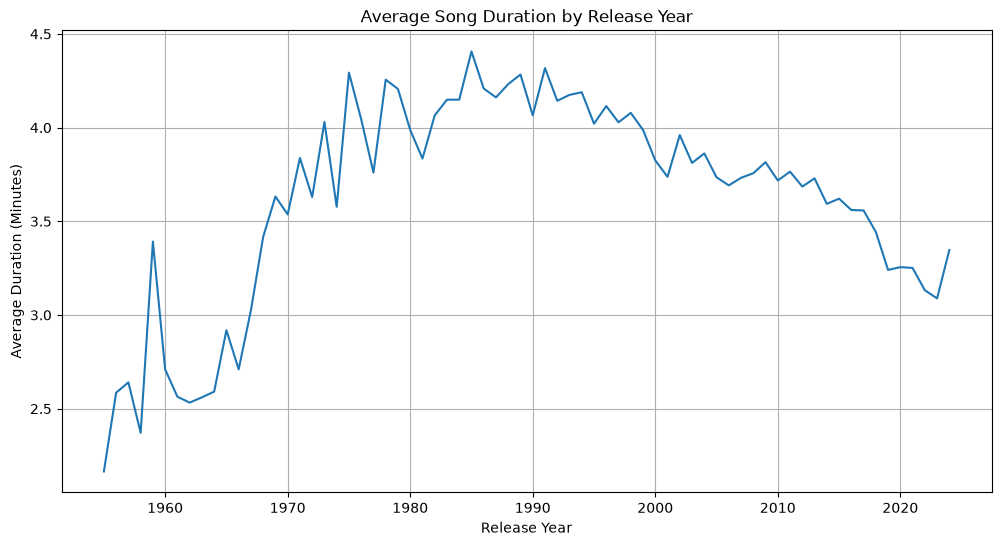

In [19]:
#Plotting to visiualise the trend
import pandas as pd
import matplotlib.pyplot as plt 

duration_year = data.groupby('Release Year')['Duration (min)'].mean()
plt.figure(figsize=(12,6))
plt.plot(duration_year.index, duration_year.values)
plt.title('Average Song Duration by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (Minutes)')
plt.grid(True)
plt.show()

<h3> Trend observations: Song Duration </h3>

- <b> Songs Became Longer During 1955–1985:</b> Possibly because of the rise of album-oriented music and drifting away from radio-friendly formats.
- <b> The Longest Songs Occurred During the 1980s:</b> with average durations exceeding 4.3 minutes.
- <b> Continuous Decline Since the Late 1980s:</b> Behavioural Intuition backs this as producers benefitted more from songs that:
  - Deliver hooks more quickly
  - Reduce listener drop-off
  - Encourage playing songs on loop
  - Generate more streams per listening session
  
Shorter songs therefore become economically advantageous.

<b> Q2. Has Music Become More Energetic Over Time? </b>

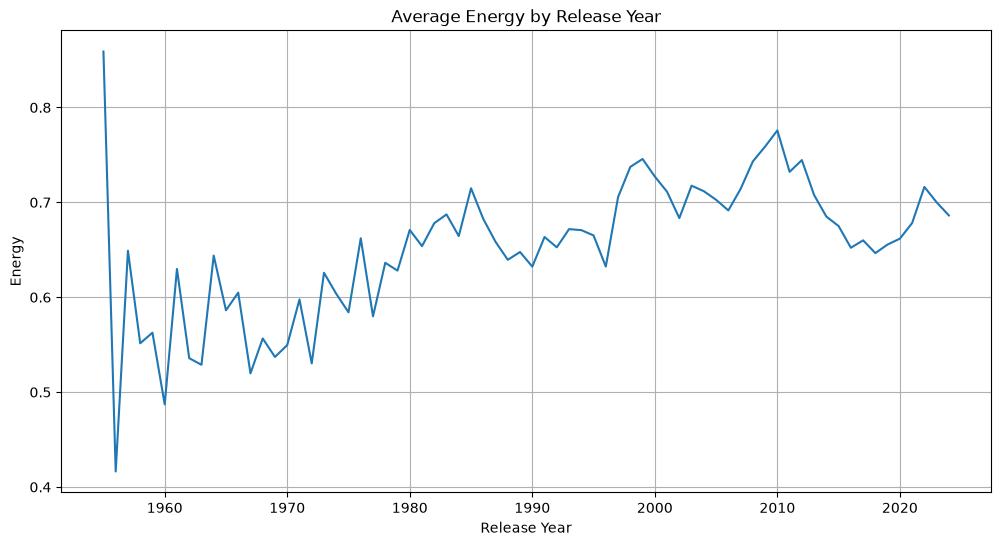

In [20]:
energy_year = data.groupby('Release Year')['Energy'].mean()
plt.figure(figsize=(12,6))
plt.plot(energy_year.index, energy_year.values)
plt.title('Average Energy by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Energy')
plt.grid(True)
plt.show()

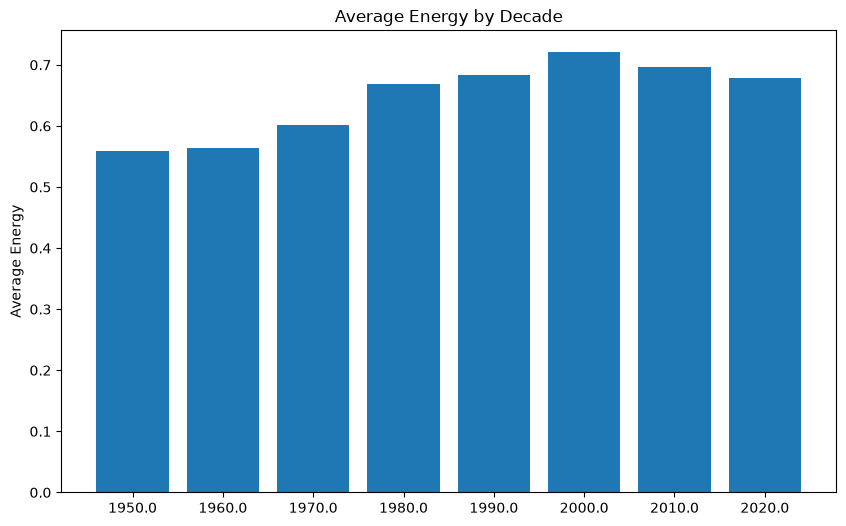

In [21]:
#Energy Component in music by decade
energy_decade = data.groupby('Decade')['Energy'].mean()

plt.figure(figsize=(10,6))
plt.bar(energy_decade.index.astype(str), energy_decade.values)
plt.title('Average Energy by Decade')
plt.ylabel('Average Energy')
plt.show()

<h3> Trend observations: Energy in Music </h3>

- <b> General Upward Trend: </b> Despite year-to-year fluctuations, the long-run trend is clearly upward.
- <b> Strong Growth Between 1970 and 2000: </b> This period coincides with:
  - Growth of amplified rock music
  - Emergence of electronic production and Increased studio technology
- <b> Peak Energy During The Early 2010s: </b> Possibly due to EDM boom and commercial pop dominance
- <b>Slight Decline After 2012: </b> Recent trends such as Bedroom pop, Lo-fi influences, Alternative pop, etc. may have softened average energy levels slightly. 
<br>
However, Modern music is still substantially more energetic than historical music.


<b> Q3. Has music become less acoustic and more digitally optimized? </b>

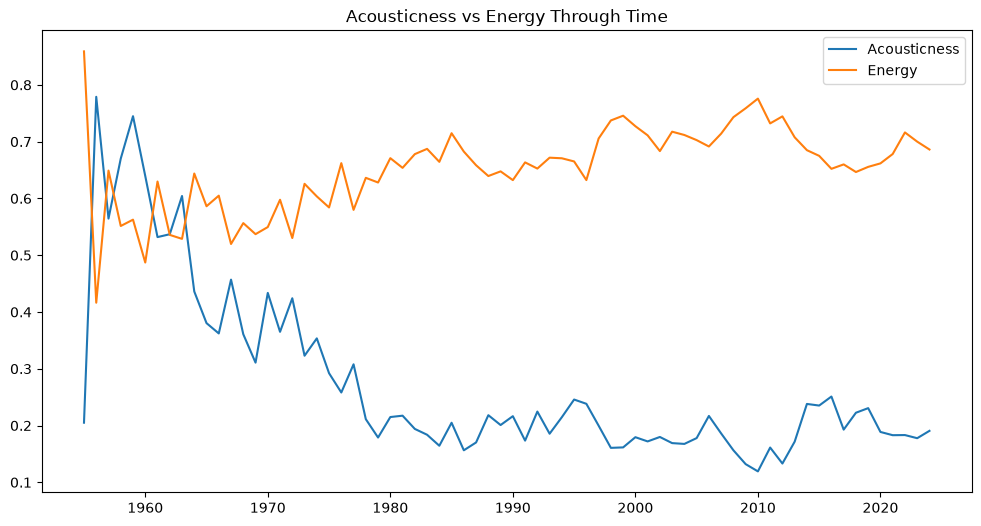

In [22]:
#Acousticness vs Energy Through Time
plt.figure(figsize=(12,6))

plt.plot(
    data.groupby('Release Year')['Acousticness'].mean(),
    label='Acousticness'
)

plt.plot(
    data.groupby('Release Year')['Energy'].mean(),
    label='Energy'
)

plt.legend()
plt.title('Acousticness vs Energy Through Time')
plt.show()

<h3> Trend observations: Acousticness </h3>

- <b> Strong Long-Term Decline in Acousticness: </b> There was a drastic shift from Live instrumentation, Acoustic recording and Minimal studio manipulation to a more digitaly optimised setup.
- <b> Energy Increases as Acousticness Decreases: </b> The relationship appears almost inverse, and is exactly what the Attention Economics framework predicts.
- <b> Divergence Widens Over Time: </b> Music production increasingly prioritizes intensity and stimulation over acoustic authenticity.
- <b>The Largest Transformation Occurs Before Streaming: </b> Radio, Electronic production and Digital recording technology had already been pushing music in this direction for decades. Thus, streaming may have accelerated an existing tendency rather than initiating it.



<b> Q4. Has Instrumental Complexity Declined? </b>

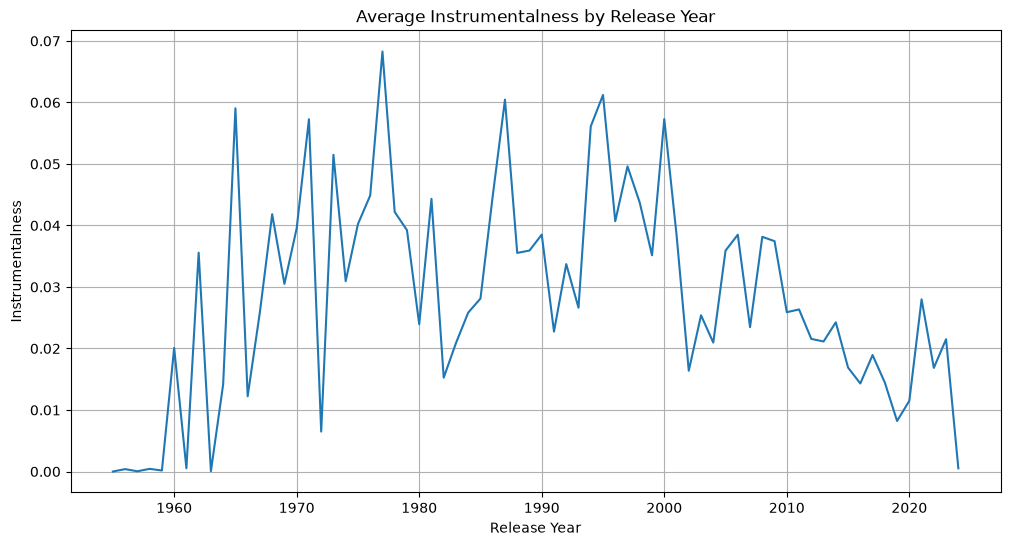

In [23]:
#Instrumental complexity over time
instrumental_year = data.groupby('Release Year')['Instrumentalness'].mean()

plt.figure(figsize=(12,6))
plt.plot(instrumental_year.index, instrumental_year.values)
plt.title('Average Instrumentalness by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Instrumentalness')
plt.grid(True)
plt.show()

<h3> Trend observations: Instrumental Complexity </h3>

- <b> Even the highest values here represent relatively low instrumentalness: </b> as popular music has historically been vocal-heavy. 
- <b> Evidence Is Not Uniform Across History: </b> There is no continuous decline or acceleration
- <b> Streaming Era Shows the Sharpest Decline: </b> This aligns with Attention Economics. When attention is scarce, long instrumental intros become a risky bet while immediate vocal engagement becomes valuable.
- <b>Supports the hypothesis </b> that modern popular music contains less instrumental content than earlier eras.

<b> Q5. Has explicit content become more common? </b>

In [24]:
#Explicit song trend over time
explicit_share = (
    data.groupby('Release Year')['Explicit']
    .mean()
    * 100
)

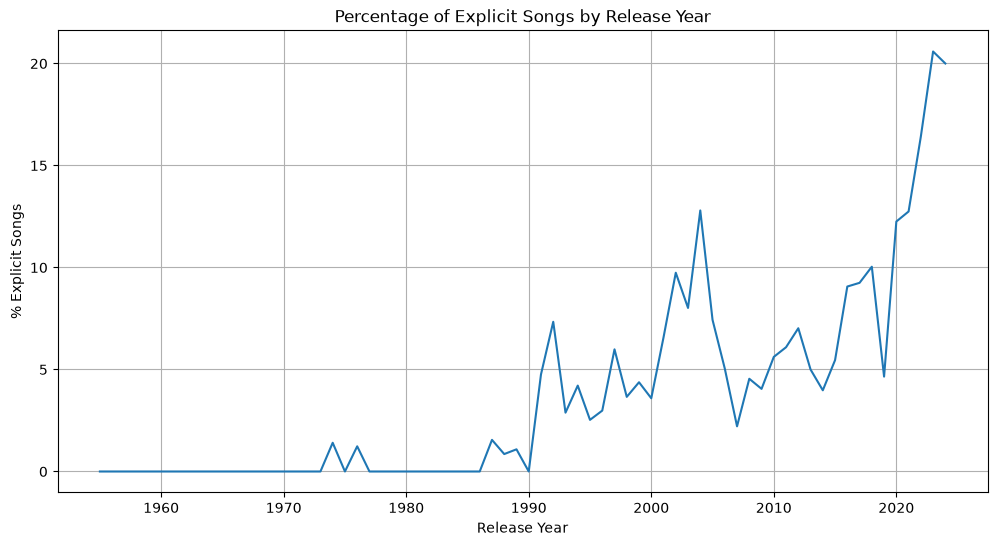

In [25]:
plt.figure(figsize=(12,6))
plt.plot(explicit_share.index, explicit_share.values)

plt.title('Percentage of Explicit Songs by Release Year')
plt.xlabel('Release Year')
plt.ylabel('% Explicit Songs')
plt.grid(True)

plt.show()

<h3> Trend observations: Explicit Content </h3>

- <b> Explicit Content Was Virtually Non-Existent Before the 1990s: </b> as it was was heavily influenced by:
  - Radio broadcasting standards,
  - Record label restrictions, and
  - Regulatory pressure
<br>
Artists generally avoided explicit language in mainstream releases.
- <b> Explicit Content Accelerates After 2000: </b> With Loosening cultural restrictions and the expansion of niche audiences, music producers were more willing to include stronger language and more provocative content.
- <b> Largest Growth Occurs During the Streaming Era: </b> Streaming platforms are not constrained by the same standards as traditional radio, so artists face fewer content restrictions and explicit content is used as a tool for emotional intensity and audience attention.
- <b>Behavioral Economics Interpretation: </b> 
The increase in explicit content reflects broader social and cultural changes in norms around language, censorship, and artistic expression. Songs with Explicit Content:
  - Create stronger emotional reactions.
  - Increase memorability.
  - Stirs up controversy and discussion.
  - and also subtly signals authenticity <br>

In a highly competitive entertainment environment, such characteristics may help content stand out.

<b> Q6. Which musical characteristics are most strongly associated with popularity? </b>

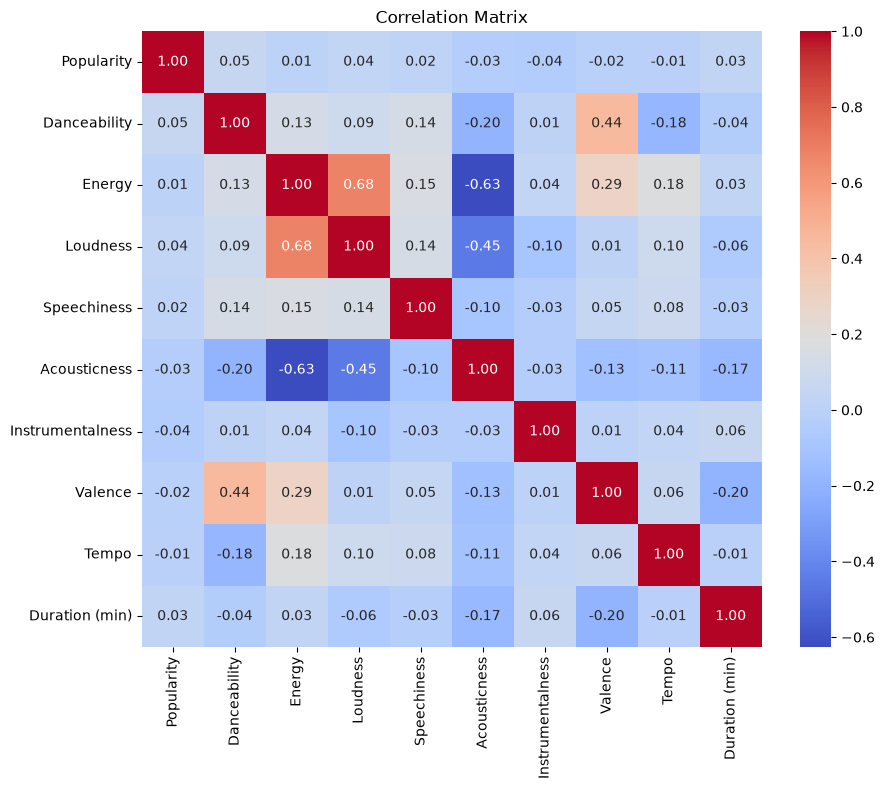

In [26]:
#First let's create a Correlation Heatmap to see how each variable relates to one another. 
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'Popularity',
    'Danceability',
    'Energy',
    'Loudness',
    'Speechiness',
    'Acousticness',
    'Instrumentalness',
    'Valence',
    'Tempo',
    'Duration (min)'
]

corr = data[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [27]:
#Popularity Correlation
pop_corr = corr['Popularity'].sort_values(ascending=False)

print(pop_corr)

Popularity          1.000000
Danceability        0.054791
Loudness            0.039573
Duration (min)      0.028832
Speechiness         0.020564
Energy              0.006872
Tempo              -0.009303
Valence            -0.015729
Acousticness       -0.031325
Instrumentalness   -0.043392
Name: Popularity, dtype: float64


<h3> Correlation Observations (The most important ones yet) </h3>

- <b> Popularity Has Extremely Weak Correlations: </b> Or you could say, in a practical sense
  - Shorter songs are not necessarily more popular.
  - More energetic songs are not necessarily more popular.
  - More danceable songs are not necessarily more popular.
  - More explicit songs are not necessarily more popular.
- <b> No Single Feature Predicts Popularity Well: </b> The strongest correlation is Danceability (0.054), which in statistics, is considered negligible. <br>
Interpretation: Popularity could depend on many factors beyond audio characteristics like Artist reputation, Marketing, Timing, Fanbase size, Cultural moments, etc.
- <b> Secondary Findings: The strongest correlations are between the music feautures themselves. </b> 
  - Energy and Loudness (0.68): Strong +ve correlation
  - Energy and Acousticness (-0.63): Strong -ve correlation, aligning with our earlier findings
  - Danceability and Valence (0.44): Moderately +ve correlation, which theoreticaly rational
- <b> Attention-Optimized Features Do Not Directly Increase Popularity: </b> The previous analyses aligned with Attention hypotheses- How music became shorter, more energetic, less acoustic. But these correlations make it clear that Attention economics may explain how music production evolved with time, rather than which songs become hits. 

<b> Q7. Did music characteristics change significantly after the emergence of streaming platforms? </b>

In [28]:
#Creating the "Streaming Era" variable ie. 2010 and over
data['Streaming Era'] = data['Release Year'] >= 2010

In [29]:
streaming_comparison = (
    data.groupby('Streaming Era')
    [
        [
            'Duration (min)',
            'Danceability',
            'Energy',
            'Acousticness',
            'Instrumentalness'
        ]
    ]
    .mean()
)

print(streaming_comparison)

               Duration (min)  Danceability    Energy  Acousticness  \
Streaming Era                                                         
False                3.862535      0.596604  0.677906      0.218484   
True                 3.552008      0.625492  0.693355      0.193293   

               Instrumentalness  
Streaming Era                    
False                  0.036061  
True                   0.019668  


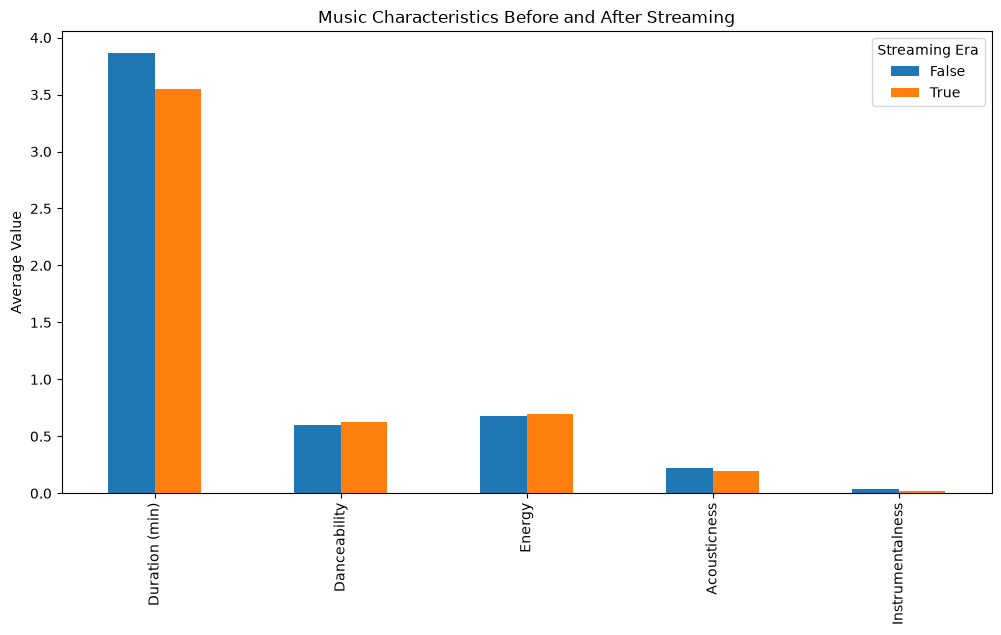

In [30]:
streaming_comparison.T.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Music Characteristics Before and After Streaming')
plt.ylabel('Average Value')
plt.show()

<h3> Trend Observations: The Streaming Era </h3>


- <b> Songs Became Shorter: </b> The streaming era rewarded fast engagement and more streams per listning session, which supports our attention economics prediction. 
- <b>Danceability Increased: </b> Due to emerging trends of having workout music, party playlists, also justifying the slight but evident increase in the energy factor in music 
- <b> Acoustics and instrumental complexity declined post the streaming era </b> Streaming-era songs appear increasingly focused on vocals, hooks and immediate engagement rather than extended instrumental sections- Aligning with our Analysis in Q3 and Q4.

The transition to the streaming era coincides with clear changes in popular music. Compared with pre-streaming releases, songs have become shorter, more energetic, more danceable, and less acoustic and instrumental, providing strong evidence of production strategies aligned with the principles of Attention Economics.

<b> Q8. Does the evidence support the Attention Economics theory of music production? </b>

The Attention Economics theory of music production is backed up by our analysis to a great extent. Music has changed a lot over the years. Songs are shorter now. They have more energy. Acousticness and instrumental complexity declined while songs with explicit content saw a rise due to relaxed regulations. These changes are even more amplified when you look at music in the streaming era. <br>
But here is the thing. These changes do not really affect how popular a song is. Let that sit. <br> 
So, while the way people pay attention to music has changed, the it's made is not what makes it a commercial success. For the latter, other factors like artist influence, marketing, and cultural trends, also play an important role.

<b> The analysis, instead of formulating sureshot variables that impacted the popularity of a song, exposes a long-term shift in how music is produced to compete for listener attention </b>